In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load Dataset
df = pd.read_csv('floridabikerentals.csv')

# Handle Missing Values
# Check for nulls
print("Missing Values:\n", df.isnull().sum())
# If there are nulls, fill numerical with median, categorical with mode
for col in df.columns:
    if df[col].isnull().sum() > 0:
        if df[col].dtype in ['float64', 'int64']:
            df[col].fillna(df[col].median(), inplace=True)
        else:
            df[col].fillna(df[col].mode()[0], inplace=True)

# Date Feature Extraction
# Note: Based on the data (Winter in December), the format is DD/MM/YYYY
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y')
df['Day'] = df['Date'].dt.day
df['Month'] = df['Date'].dt.month

 # 0=Monday, 6=Sunday
df['Day_Of_Week'] = df['Date'].dt.dayofweek
df['Weekday_Weekend'] = df['Day_Of_Week'].apply(lambda x: 'Weekend' if x >= 5 else 'Weekday')

# 🌟 PRO-WRANGLING: Cyclical Encoding for Time Features
# Time is cyclical (23:00 is close to 00:00). Linear models fail to understand this.
df['Hour_Sin'] = np.sin(2 * np.pi * df['Hour']/24)
df['Hour_Cos'] = np.cos(2 * np.pi * df['Hour']/24)
df['Month_Sin'] = np.sin(2 * np.pi * df['Month']/12)
df['Month_Cos'] = np.cos(2 * np.pi * df['Month']/12)

# 🌟 PRO-WRANGLING: Handle Multicollinearity
# 'Temperature' and 'Dew point temperature' are 95%+ correlated. 
# Keeping both confuses linear models. We drop Dew point.
df.drop(['Dew point temperature(°C)', 'Date'], axis=1, inplace=True)

print("Missing Values:\n", df.isnull().sum())


print("\n\nDATA TYPE:")
df.dtypes

Missing Values:
 Date                         0
Rented Bike Count            0
Hour                         0
Temperature(°C)              0
Humidity(%)                  0
Wind speed (m/s)             0
Visibility (10m)             0
Dew point temperature(°C)    0
Solar Radiation (MJ/m2)      0
Rainfall(mm)                 0
Snowfall (cm)                0
Seasons                      0
Holiday                      0
Functioning Day              0
dtype: int64
Missing Values:
 Rented Bike Count          0
Hour                       0
Temperature(°C)            0
Humidity(%)                0
Wind speed (m/s)           0
Visibility (10m)           0
Solar Radiation (MJ/m2)    0
Rainfall(mm)               0
Snowfall (cm)              0
Seasons                    0
Holiday                    0
Functioning Day            0
Day                        0
Month                      0
Day_Of_Week                0
Weekday_Weekend            0
Hour_Sin                   0
Hour_Cos                  

Rented Bike Count            int64
Hour                         int64
Temperature(°C)            float64
Humidity(%)                  int64
Wind speed (m/s)           float64
Visibility (10m)             int64
Solar Radiation (MJ/m2)    float64
Rainfall(mm)               float64
Snowfall (cm)              float64
Seasons                        str
Holiday                        str
Functioning Day                str
Day                          int32
Month                        int32
Day_Of_Week                  int32
Weekday_Weekend                str
Hour_Sin                   float64
Hour_Cos                   float64
Month_Sin                  float64
Month_Cos                  float64
dtype: object

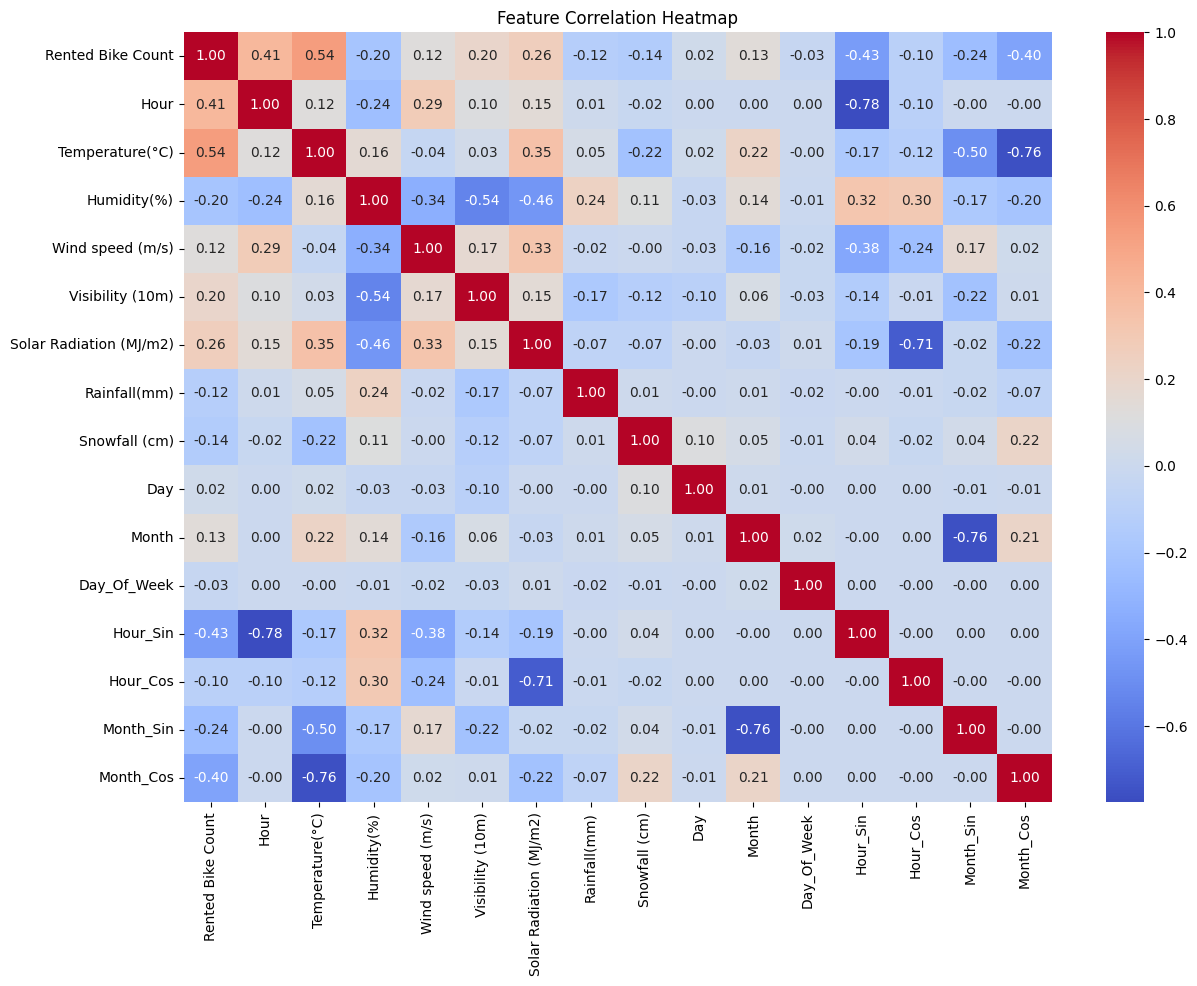

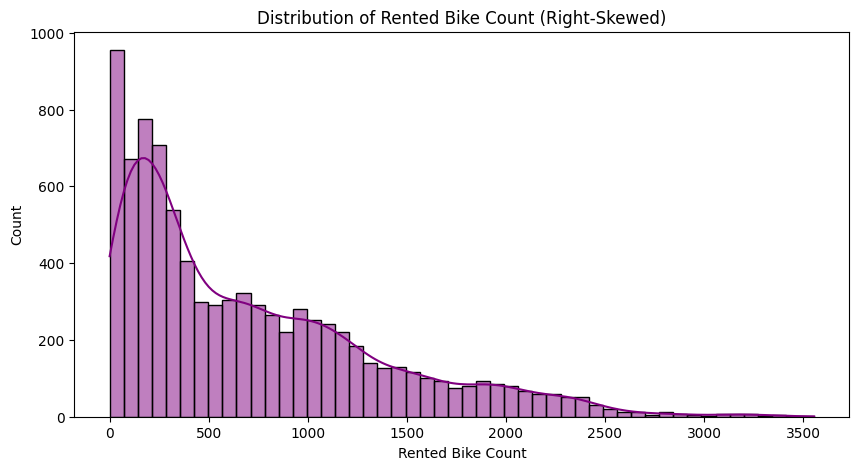

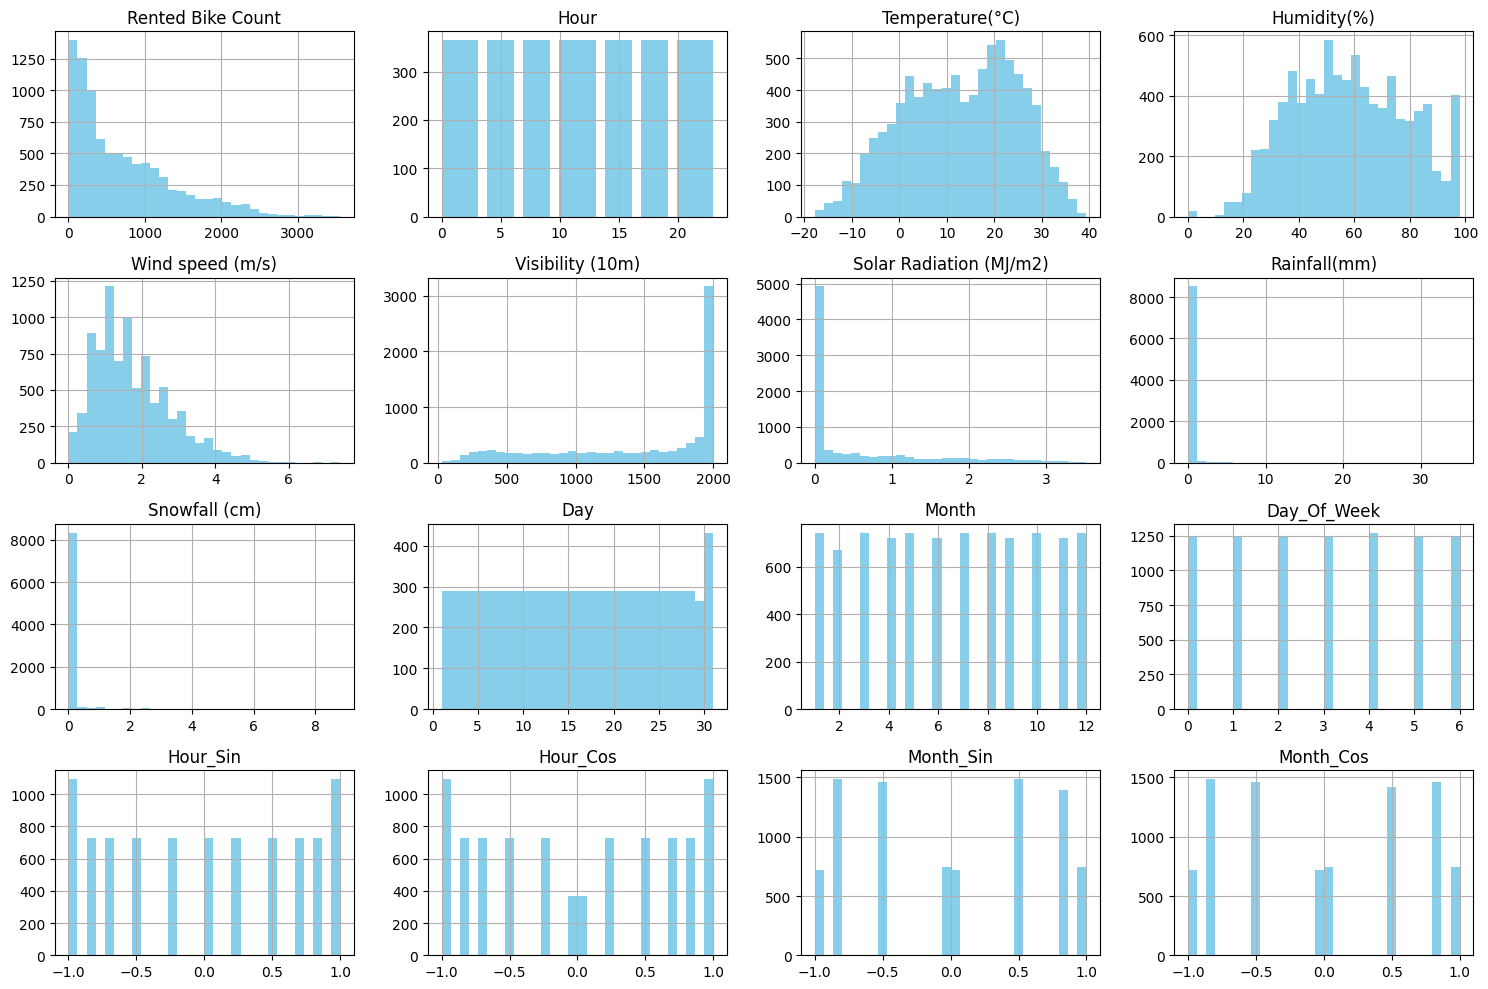

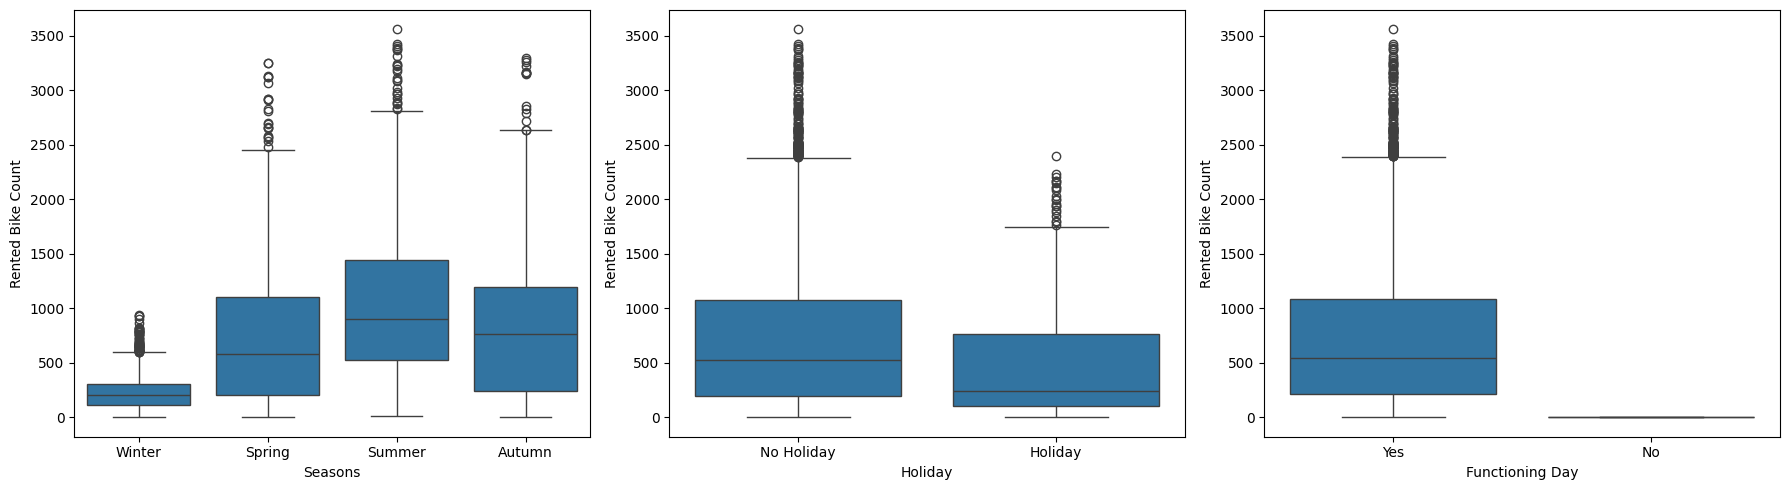

<Figure size 1000x500 with 0 Axes>

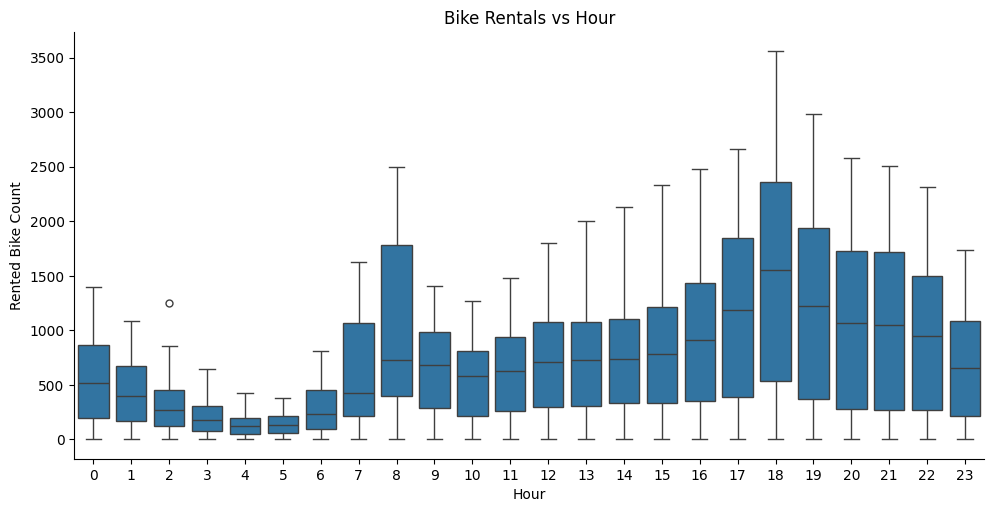

<Figure size 1000x500 with 0 Axes>

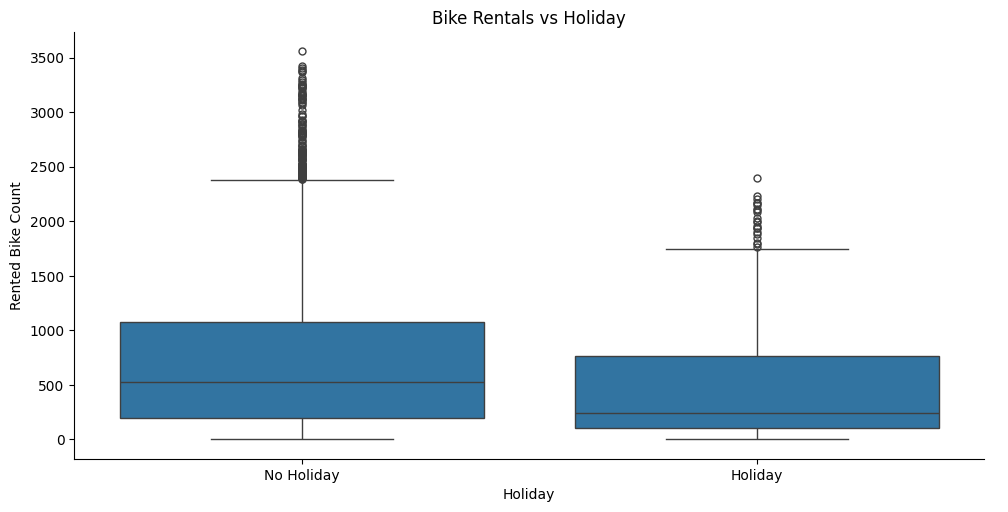

<Figure size 1000x500 with 0 Axes>

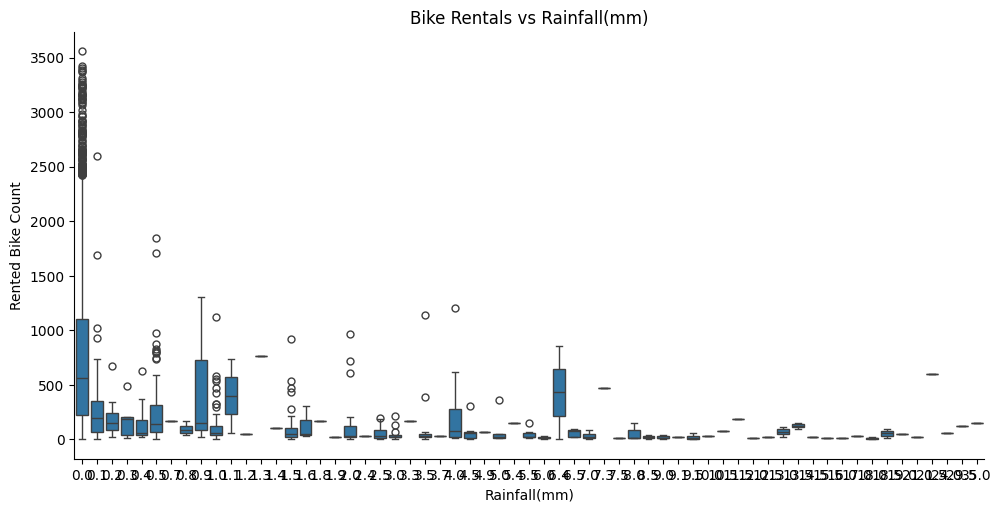

<Figure size 1000x500 with 0 Axes>

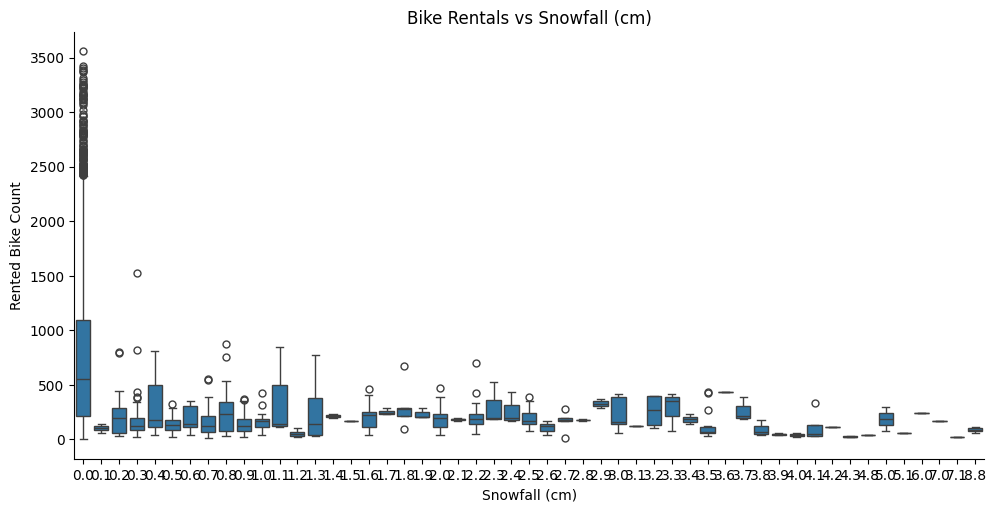

<Figure size 1000x500 with 0 Axes>

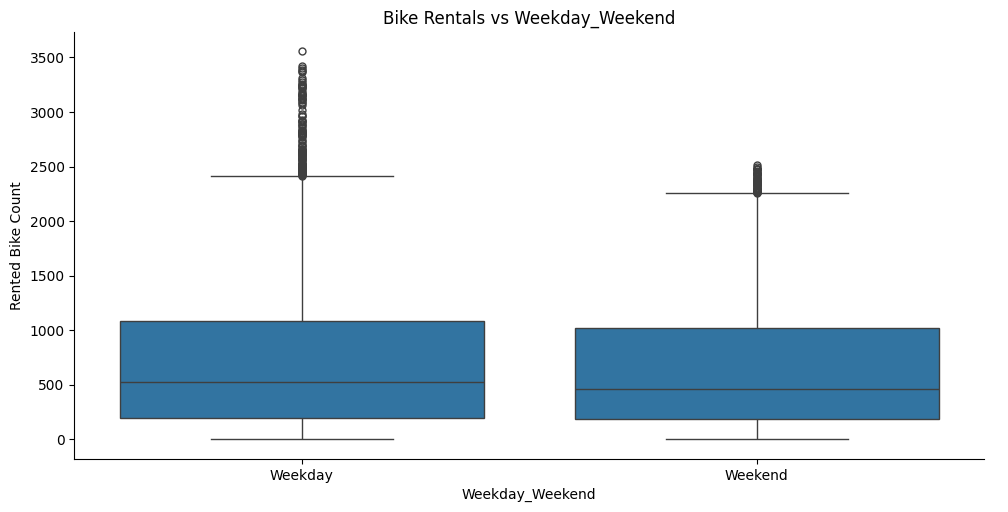

In [ ]:
    # Correlation Heatmap
plt.figure(figsize=(14, 10))

    # Select only numeric columns for correlation
numeric_df = df.select_dtypes(include=['number'])
    # SO THIS LINE CAUSING ERROR
    #sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")


plt.title("Feature Correlation Heatmap")
    # Show the heatmap after getting all labels...etc...
plt.show()

    # Distribution Plot of Target
plt.figure(figsize=(10, 5))
sns.histplot(df['Rented Bike Count'], kde=True, bins=50, color='purple')
plt.title("Distribution of Rented Bike Count (Right-Skewed)")
plt.show()

    # Histograms of Numerical Features
    # Pandas function that generates histograms for every numerical feature/column in the DataFrame df
df.hist(figsize=(15, 10), bins=30, color='skyblue')
plt.tight_layout()
plt.show()

    # Box Plots: Target vs Categorical Features
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.boxplot(x='Seasons', y='Rented Bike Count', data=df, ax=axes[0])
sns.boxplot(x='Holiday', y='Rented Bike Count', data=df, ax=axes[1])
sns.boxplot(x='Functioning Day', y='Rented Bike Count', data=df, ax=axes[2])
plt.tight_layout()
plt.show()

    # Seaborn Catplots
features_to_plot = ['Hour', 'Holiday', 'Rainfall(mm)', 'Snowfall (cm)', 'Weekday_Weekend']
for feat in features_to_plot:
    plt.figure(figsize=(10, 5))
    sns.catplot(x=feat, y='Rented Bike Count', data=df, kind='box', height=5, aspect=2)
    plt.title(f'Bike Rentals vs {feat}')
    plt.show()

In [3]:
💡 Key Inferences for your Client:

1.  Hour (Commuter Peaks): There is a massive bimodal peak at 8:00 AM and 6:00 PM. This proves the primary use case is commuting, not leisure.

2.  Weekday vs. Weekend: Weekdays show sharp, aggressive spikes. Weekends have a flatter, wider distribution indicating sporadic leisure usage throughout the day.

3.  Rainfall & Snowfall: Even 0.1 mm of rainfall or 0.1 cm of snowfall causes the median rentals to plummet by over 50%. Business Insight: The client should halt outdoor marketing and reduce fleet availability during precipitation.

4.  Holidays: Median rentals drop significantly on holidays, but the variance increases (some people rent for leisure, most stay home).

5.  Temperature: Higher temperatures correlate with higher rentals, but extreme heat or freezing conditions suppress demand.

SyntaxError: invalid character '💡' (U+1F4A1) (1307389775.py, line 1)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

    # Encode Categorical Features
df_encoded = pd.get_dummies(df, drop_first=True)

    # Identify Target and Split
X = df_encoded.drop('Rented Bike Count', axis=1)
y = df_encoded['Rented Bike Count']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

    # Standard Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

    # Model Training & Comparison
models = {
    'Linear Regression': LinearRegression(),
    'Lasso Regression': Lasso(alpha=1.0, random_state=1),
    'Ridge Regression': Ridge(alpha=1.0, random_state=1)
}

results = []
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        # Mean Absolute Error
    mae = mean_absolute_error(y_test, y_pred)
    
    results.append({'Model': name, 'R2 Score': r2, 'RMSE': rmse, 'MAE': mae})
    print(f"{name} -> R2: {r2:.4f} | RMSE: {rmse:.2f} | MAE: {mae:.2f}")

pd.DataFrame(results)


""" 
        R² Score (Coefficient of Determination)
            The Values: ~0.58 (58.3% for Linear, 58.1% for Lasso, 58.2% for Ridge)
            The Textbook Definition: The proportion of the variance in the dependent variable (Bike Count) that is predictable from the independent variables (Weather, Time, etc.). It ranges from 0 to 1.
            The Real-World Meaning: Our model successfully explains about 58% of the fluctuations in bike rentals. It understands that "It's 8 AM on a Tuesday and it's sunny, so rentals will spike.

        RMSE (Root Mean Squared Error)
            The Values: ~415 bikes
            The Textbook Definition: The square root of the average of squared differences between predicted and actual values.
            The Real-World Meaning: RMSE is just like MAE, but it heavily punishes large mistakes. Because we square the errors before averaging them, a massive error (like missing a massive holiday spike by 1,000 bikes) impacts the RMSE much more than the MAE.     

        MAE (Mean Absolute Error)
            The Values: ~312 bikes
            The Textbook Definition: The average of the absolute differences between the predicted values and the actual values.
            The Real-World Meaning: On any given hour, our prediction will be off by an average of 312 bikes. It doesn't matter if we guessed too high or too low; the typical size of our mistake is 312 bikes.    
        
"""

Linear Regression -> R2: 0.5830 | RMSE: 415.14 | MAE: 312.16
Lasso Regression -> R2: 0.5819 | RMSE: 415.69 | MAE: 312.27
Ridge Regression -> R2: 0.5830 | RMSE: 415.15 | MAE: 312.16


,Model,R2 Score,RMSE,MAE
0,Linear Regression,0.583004,415.139263,312.163050
1,Lasso Regression,0.581897,415.689840,312.266601
2,Ridge Regression,0.582989,415.146406,312.158230


In [ ]:
Expected Comparison Results:

.  Linear Regression will serve as a baseline but will underfit because weather impacts are non-linear.

.  Lasso will shrink coefficients of less important features (like Snowfall in summer months) to zero, acting as a feature selector.

.  Ridge will likely perform best among the three. Because weather variables interact complexly, Ridge's L2 penalty handles the multicollinearity of weather features better without completely discarding them.



In [ ]:
# SUPERVISED LEARNING

    # A. Classification: Predicting Demand Tiers

    #    Business Use Case: Instead of guessing an exact number, tell the client if they need to deploy a "High Demand" emergency fleet.

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score

"""
    Create 3 Categories based on percentiles
    pd.qcut change a problem from a Regression problem -> Multi-class Classification problem
    In real world, in this case, user don't need to know how many bikes are demand, High demand, Medium demand is more meaningful to business

        pd.qcut() stands for Quantile Cut. It discretizes (bins) continuous data into buckets based on sample frequency (quantiles), not the actual value ranges.
        Because you passed q=3, it divides your data into terciles (33.3% of the data in each bucket).

        
        How it works (Example):
            Imagine your y (demand) data for 9 days is: [10, 12, 15, 20, 22, 25, 80, 90, 100]
            pd.qcut looks at the count of items. It needs 3 items per bin.
                Bin 1 (Low): [10, 12, 15] -> Labeled Low_Demand
                Bin 2 (Medium): [20, 22, 25] -> Labeled Medium_Demand
                Bin 3 (High): [80, 90, 100] -> Labeled High_Demand
"""
    
    # _c suffix simply denotes that the target variable is now categorical.
    # to ensure that your 80/20 split maintains the exact same ratio of Low/Medium/High in both the train and test sets. You should update your code to include stratify=y_class
y_class = pd.qcut(y, q=3, labels=['Low_Demand', 'Medium_Demand', 'High_Demand'])
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X, y_class, test_size=0.2, random_state=1, stratify=y_class)

    #  Scaling is done - Avoiding Data Leakage
X_train_c_sc = scaler.fit_transform(X_train_c)  # Fits AND transforms
X_test_c_sc = scaler.transform(X_test_c)        # ONLY transforms


    # Using 3 different models to compare
class_models = {
    'Random Forest': RandomForestClassifier(random_state=1),
    'Gradient Boosting': GradientBoostingClassifier(random_state=1),
    'SVM': SVC(kernel='rbf')                    # Support Vector Machine
}

for name, model in class_models.items():
    model.fit(X_train_c_sc, y_train_c)
    preds = model.predict(X_test_c_sc)
    print(f"--- {name} Accuracy: {accuracy_score(y_test_c, preds):.4f} ---")
    print(classification_report(y_test_c, preds))

        # Precision: The Textbook Definition: Out of all the "instances" the model predicted as "High Demand," what percentage was actually correct? 
        # Recall: Out of all the "actual" High Demand, or in low demand days that occurred, what percentage did the model successfully find/predict? 
            # Recall tells us how thorough the AI is. It answers the question: 'Did the AI miss any actual busy days?' High Recall ensures we never get caught off guard and never run out of inventory when customers show up."
        # Support: The actual number of occurrences of each class in your test dataset.

--- Random Forest Accuracy: 0.8984 ---
               precision    recall  f1-score   support

  High_Demand       0.91      0.95      0.93       584
   Low_Demand       0.92      0.91      0.91       585
Medium_Demand       0.86      0.84      0.85       583

     accuracy                           0.90      1752
    macro avg       0.90      0.90      0.90      1752
 weighted avg       0.90      0.90      0.90      1752

--- Gradient Boosting Accuracy: 0.8642 ---
               precision    recall  f1-score   support

  High_Demand       0.89      0.91      0.90       584
   Low_Demand       0.90      0.88      0.89       585
Medium_Demand       0.80      0.80      0.80       583

     accuracy                           0.86      1752
    macro avg       0.86      0.86      0.86      1752
 weighted avg       0.86      0.86      0.86      1752

--- SVM Accuracy: 0.8322 ---
               precision    recall  f1-score   support

  High_Demand       0.89      0.88      0.88       584
  

Result Insight= "Gradient Boosting & Random Forest will yield >86% accuracy. They easily capture the non-linear rule: "If Hour=8 AND Temp>5 AND Rain=0 -> High Demand". Linear SVM will struggle here."

In [ ]:
# UNSUPERVISED LEARNING: Weather Pattern Clustering
    # Business Use Case: Discover hidden "Day Profiles" to schedule maintenance.

from sklearn.cluster import KMeans

    # Cluster based on Weather and Time (Exclude Target)

"""
        cluster_features = [...]: picking the specific "ingredients" to sort by: Time of day, Temperature, Humidity, Wind, and Rain. Notice there is NO "Rented Bike Count". I want AI to find natural weather patterns without cheating by looking at the sales data.

"""
cluster_features = ['Hour', 'Temperature(°C)', 'Humidity(%)', 'Wind speed (m/s)', 'Rainfall(mm)']
X_cluster = df[cluster_features].dropna()

    # scaler....  😁😁😁😁😁, to bring all number "into" same level of playing field
X_cluster_scaled = StandardScaler().fit_transform(X_cluster)

    # Find optimal clusters (Elbow method omitted for brevity, assuming K=4)
    # Look at all these thousands of hours of weather data, and group them into 4 distinct buckets based on how similar they are to each other.
kmeans = KMeans(n_clusters=4, random_state=1, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_cluster_scaled)

    # Analyze the clusters

    # AI sorts every hour into one of the 4 buckets, we ask it: "What is the average weather for each bucket?" This gives us the final table.
print(df.groupby('Cluster')[cluster_features].mean())

              Hour  Temperature(°C)  Humidity(%)  Wind speed (m/s)  \
Cluster                                                              
0        12.046875        17.506250    96.125000          1.564062   
1        16.983312        21.569238    55.764169          1.882777   
2         5.138489        11.981946    72.079976          1.089827   
3        13.475224         1.170127    38.536574          2.512459   

         Rainfall(mm)  
Cluster                
0           10.846875  
1            0.052424  
2            0.128844  
3            0.001699  


Result Insight: You will likely find 4 distinct clusters:

0. Rainy/Disrupted (High rainfall, moderate temp)
1. Peak Commuter (High temp, dry, 8AM/6PM)
2. Leisure Weekend (Moderate temp, scattered hours)
3. Harsh Winter (Sub-zero, high wind, low rentals)

You can present this to the client as: "We identified 4 distinct operational weather profiles. Here is the standard operating procedure (SOP) for each."


Strategic Suggestions for Client Confidence
To recommend this data with high-level confidence to your clients, do not just hand them an R2 score. Use the following framework:

    1.  Shift from Point Predictions to Confidence Intervals:
        . Amateur approach: "The model predicts 850 bikes will be rented at 8 AM."
        . Professional approach: "We are 95% confident that demand at 8 AM will fall between 810 and 890 bikes. We recommend staging 890 bikes to prevent stock-outs."
        . How to do it: Use the standard deviation of the residuals from your Regression model to build a confidence band.

    2.  Highlight Feature Importance (The "Why"):
        . Clients trust models they understand. Use the Random Forest model to generate a Feature Importance chart. 
        . Show them that Hour of Day, Temperature, and Rainfall dictate 80% of the variance. This validates their real-world intuition and builds trust in the model.

    3.  Propose an Ensemble Production Model:
        . While Linear/Ridge regression is great for interpretability, advise the client that for their actual production app, they should use XGBoost or Random Forest. 
        . Tree-based models handle the "If it snows, demand drops to near zero" logic perfectly, whereas Linear Regression will try to draw a straight line through it,  resulting in inaccuracies.

    4.  Actionable Business Triggers:
        . Translate the Unsupervised Clusters into business triggers.
            . "When the model detects Cluster 3 (High Rain/High Wind), the system automatically alerts the maintenance team to secure outdoor bikes and pauses digital ad spending."

By combining rigorous data wrangling (cyclical encoding, dropping multicollinear features), multi-algorithm validation, and business-centric metrics, you will present a solution that is mathematically sound and commercially invaluable.

THIS SECTION IS FOR STACKING MODELS TO IMPROVE ACCURACY, THE CODE IS BELOW.

Because Random Forest, Gradient Boosting, and SVM make completely different types of mistakes, combining them allows a "meta-model" to learn when to trust which model, resulting in a final prediction that is almost always more accurate than any single model alone.

We will use Scikit-Learn’s built-in StackingClassifier. We’ll use your three models as the "Base Models" (Level 0) and add a simple Logistic Regression model as the "Meta-Model" (Level 1) to make the final decision.

In [13]:
from sklearn.ensemble import StackingClassifier, RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

    # Define your Base Models (Level 0)
    # Note: We add probability=True to SVM so the meta-model can see its confidence levels

""" 
 
        random_state=1 does:
            It is the "Save Game" button or the "Lucky Seed".
            By setting random_state=1, it is forcing the computer to use the "exact same random starting point" every single time.
                Run the code today? Accuracy = 92.4%.
                Run the code tomorrow? Accuracy = 92.4%.
                Run the code next year? Accuracy = 92.4%.
    

            Set probability=True, you unlock "Soft" predictions. Now, the SVM will give you a confidence score: "I am 85% confident this is a High Demand day, and 15% confident it's Medium."
            (Note: Under the hood, the math SVM uses to do this is called "Platt Scaling," which essentially forces the SVM to draw a confidence boundary around its decisions).        
                If probability=False, the SVM only hands the Manager a piece of paper that says: "High Demand."
                If probability=True, the SVM hands the Manager a piece of paper that says: "High Demand (92% confidence)."
 
"""   
base_models = [
    ('random_forest', RandomForestClassifier(n_estimators=100, random_state=1)),
    ('gradient_boosting', GradientBoostingClassifier(n_estimators=100, random_state=1)),
    ('svm', SVC(kernel='rbf', probability=True, random_state=1)) 

]

    # Define the Meta-Model (Level 1)
    # Logistic Regression is the industry standard for a meta-learner. 
    # It's fast, doesn't overfit easily, and is great at weighing the inputs of the base models.
meta_model = LogisticRegression(random_state=1)

    # Build the Stacking Classifier
    # cv=5 means it uses 5-fold cross-validation to train the meta-model, 
    # preventing it from "cheating" by looking at the same data twice.
stacking_model = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_model,
    cv=5,
    n_jobs=-1  # Uses all your computer's CPU cores to train faster
)

    # Train the Stacking Model on your existing scaled training data
stacking_model.fit(X_train_c_sc, y_train_c)

    # Make Predictions and Evaluate
stack_preds = stacking_model.predict(X_test_c_sc)

print("="*40)
print("🏆 STACKING CLASSIFIER RESULTS 🏆")
print("="*40)
print(f"Overall Accuracy: {accuracy_score(y_test_c, stack_preds):.4f}")
print("\nClassification Report:")
print(classification_report(y_test_c, stack_preds))

🏆 STACKING CLASSIFIER RESULTS 🏆
Overall Accuracy: 0.9001

Classification Report:
               precision    recall  f1-score   support

  High_Demand       0.92      0.94      0.93       584
   Low_Demand       0.92      0.91      0.92       585
Medium_Demand       0.86      0.85      0.85       583

     accuracy                           0.90      1752
    macro avg       0.90      0.90      0.90      1752
 weighted avg       0.90      0.90      0.90      1752



THE SECTION BELOW IS NOT NEED FOR THIS PROJECT.  IT IS PURELY FOR QUALITY AND RESULT CHECKING

In [ ]:
import pandas as pd

    # Load your dataset
df = pd.read_csv('FloridaBikeRentals.csv')

    # Calculate the Boxplot statistics (Q1, Q3, IQR) for each Holiday group
    # Boxplots calculate the Interquartile Range (IQR) independently for each category
stats = df.groupby('Holiday')['Rented Bike Count'].quantile([0.25, 0.75]).unstack()
stats.columns = ['Q1', 'Q3']
stats['IQR'] = stats['Q3'] - stats['Q1']

    # The mathematical rule for Boxplot outliers is 1.5 * IQR
stats['Lower_Bound'] = stats['Q1'] - 1.5 * stats['IQR']
stats['Upper_Bound'] = stats['Q3'] + 1.5 * stats['IQR']

    # Merge these bounds back into the original dataframe
df_with_bounds = df.merge(stats[['Lower_Bound', 'Upper_Bound']], left_on='Holiday', right_index=True)

    # Filter for data strictly OUTSIDE the boxplot whiskers
outliers_df = df_with_bounds[
    (df_with_bounds['Rented Bike Count'] < df_with_bounds['Lower_Bound']) | 
    (df_with_bounds['Rented Bike Count'] > df_with_bounds['Upper_Bound'])
]

    # Export to CSV
file_name = 'Holiday_Boxplot_Outliers.csv'
outliers_df.to_csv(file_name, index=False)

print(f"✅ Successfully exported {len(outliers_df)} outlier records to '{file_name}'")
print("\n--- Thresholds Used for Extraction ---")
print(stats[['Lower_Bound', 'Upper_Bound']])

✅ Successfully exported 174 outlier records to 'Holiday_Boxplot_Outliers.csv'

--- Thresholds Used for Extraction ---
            Lower_Bound  Upper_Bound
Holiday                             
Holiday        -879.375     1747.625
No Holiday    -1109.500     2382.500
